**Goal: Predict whether a piece of digital evidence is valid or suspicious using Python, weighted features, and ML.**

In this project, I built a simple digital evidence classification system using Python and machine learning. I started by creating a dataset of evidence files with features like file size, keywords found, time logged, and source type (USB, Email, Cloud). I manually converted categorical features (like source) into numeric values then calculated a weighted score for each file to make predictions on whether it was “valid” or “suspicious.” I visualized the data using bar charts and scatter plots to understand patterns and feature influence. Finally, I implemented a Decision Tree classifier from scikit-learn, splitting the dataset into training and testing sets to teach the model patterns and evaluate its performance. I measured the model’s accuracy to see how well it predicted unseen evidence, combining basic algebra, weighted sums, statistics, and decision rules. This project demonstrates feature engineering, visualization, and machine learning classification.

In [5]:
!pip install pandas matplotlib seaborn scikit-learn


In [7]:
import pandas as pd

**CREATE DATASETS**

In [8]:
data = {
    "file_name": ["File1", "File2", "File3", "File4", "File5"],
    "source": ["USB", "Email", "Cloud", "USB", "Email"],
    "size_MB": [50, 10, 200, 5, 70],
    "keywords_found": [5, 20, 0, 15, 8],
    "time_logged": [2, 23, 15, 1, 18],
    "actual": ["valid", "suspicious", "valid", "suspicious", "valid"]
}

df = pd.DataFrame(data)  #converts your dictonary data in pandas dataframe, its like a excel table in python.

In [9]:
df.to_csv("evidence.csv", index=False) #saves dataframe into csv file and index prevents python from writing row numbers into the csv.

print("CSV created successfully!")
df.head()  #displays first five rows of your dataframe.

CSV created successfully!


,file_name,source,size_MB,keywords_found,time_logged,actual
0,File1,USB,50,5,2,valid
1,File2,Email,10,20,23,suspicious
2,File3,Cloud,200,0,15,valid
3,File4,USB,5,15,1,suspicious
4,File5,Email,70,8,18,valid


In [10]:
import pandas as pd


In [11]:

df = pd.read_csv("evidence.csv")  #Reads the CSV file back into a pandas DataFrame. df now contains the same table you saved earlier. This step simulates loading real data from a file, like you would in a real project.
print(df.head()) #Shows the first 5 rows of the DataFrame loaded from the CSV. Confirms your CSV was saved and read correctly.

  file_name source  size_MB  keywords_found  time_logged      actual
0     File1    USB       50               5            2       valid
1     File2  Email       10              20           23  suspicious
2     File3  Cloud      200               0           15       valid
3     File4    USB        5              15            1  suspicious
4     File5  Email       70               8           18       valid


**Map Categorical Features**

In [14]:
def source_value (source): #this funxtion converts source value into nureical values.
 if source == "USB":
  return 1  #if the source is usb return 1, we assume its very suspisious.
 elif source == "Email":
  return 0.8 #if the source is email return 0.8, we assume its less suspisious than usb.
 else:
  return 0.5 #if the source is anything else return 0.5, its least suspisious amongst all.
df ["source_value"] = df["source"].apply(source_value) #This line takes every value in the "source" column, runs it through the source_value() function to convert it into a number, and stores the results in a new column called "source_num".

**Assign Feature Weights**

In [15]:
weights = {     #assigning weight to each feature, which means how much importance a feature holds in the final prediction.
    "size_MB": 0.2,
    "keywords_found": 0.5,
    "time_logged": 0.1,
    "source_num": 0.2
}

**Weighted Prediction Function**

In [16]:
def predict_evidence(row, threshold):
    total = (
        row["size_MB"] * weights["size_MB"] +
        row["keywords_found"] * weights["keywords_found"] +
        row["time_logged"] * weights["time_logged"] +
        row["source_num"] * 100 * weights["source_num"]  # scale source
    )
    return "suspicious" if total >= threshold else "valid"


**Calculate Threshold**

In [17]:
threshold = round(
    sum(
        df["size_MB"]*weights["size_MB"]+
        df["keywords_found"]*weights["keywords_found"]+
        df["time_logged"]*weights["time_logged"]+
        df["source_num"]*weights["source_num"]
    )/len(df)
)
print("Threshold:",threshold)

Threshold: 20


**Apply Prediction & Evaluate Accuracy**

In [24]:
correct = 0 #just making a counter to track how many predictions are correct

df["prediction"] = df.apply(lambda row: predict_evidence(row,threshold), axis=1) #this line runs the predict_evidence function in each row and saves the return result as new column called prediction

for idx, row in df.iterrows(): #this loops throw each dataframe, idx= row number(0,1,2..), row= actual row data
  print(f"{row['file_name']} -> Predicted:{row['prediction']}, Actual:{row['actual']}")
  if row["prediction"] == row["actual"]:
    correct += 1

accuracy = correct / len(df)
print("\nAccuracy:", round(accuracy*100,2),"%")


File1 -> Predicted:suspicious, Actual:valid
File2 -> Predicted:suspicious, Actual:suspicious
File3 -> Predicted:suspicious, Actual:valid
File4 -> Predicted:suspicious, Actual:suspicious
File5 -> Predicted:suspicious, Actual:valid

Accuracy: 40.0 %


**Add Visualizations**

1. Count of valid vs suspicious:

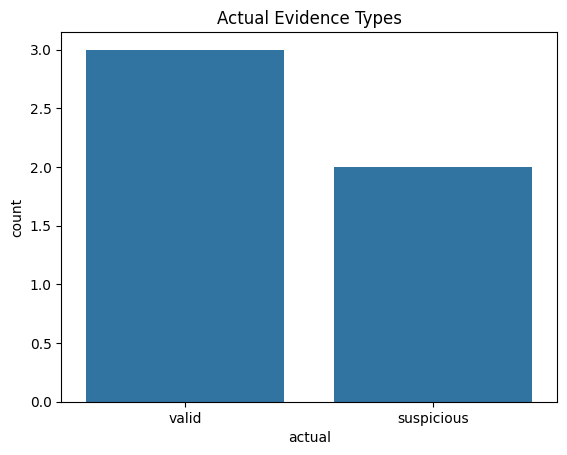

<Axes: xlabel='prediction', ylabel='count'>

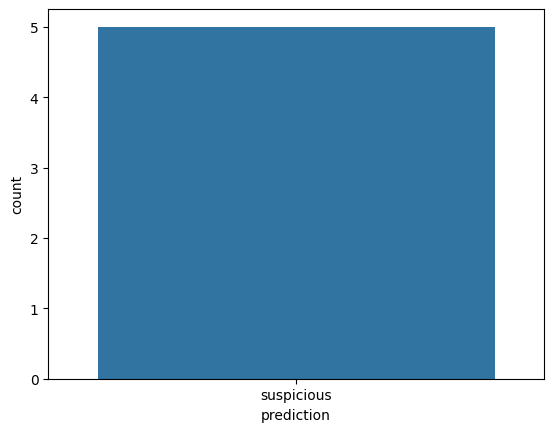

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="actual", data=df) #looks at the actual column in the dataframe, counts how many times each category appears and draws a bar graph.
plt.title("Actual Evidence Types")
plt.show()
sns.countplot(x="prediction", data=df) #now it counts value of prediction.



2. Scatter plot: keywords vs total score (to see pattern)

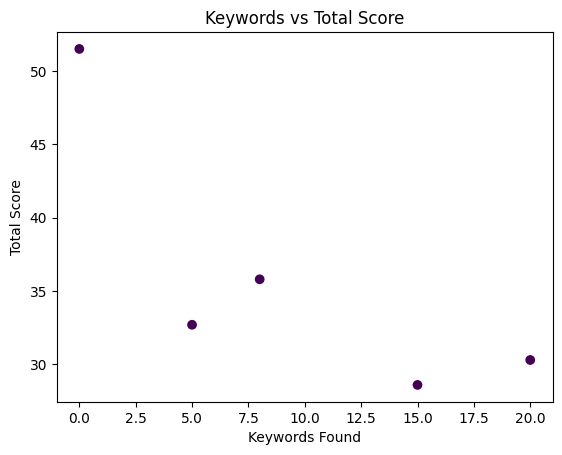

In [27]:
df["total_score"] = (
    df["size_MB"] * weights["size_MB"] +
    df["keywords_found"] * weights["keywords_found"] +
    df["time_logged"] * weights["time_logged"] +
    df["source_num"] * 100 * weights["source_num"]
)  #multipies each colum by its weight, adds everything together, store results in a new column called "total_score"

plt.scatter(df["keywords_found"], df["total_score"], c=df["prediction"].map({"valid":0, "suspicious":1})) #df["keywords_found"]=x axis, df["total_score"]= y axis, c =color of each point
plt.xlabel("Keywords Found")
plt.ylabel("Total Score")
plt.title("Keywords vs Total Score")
plt.show()


**ML Upgrade**

In [31]:
from sklearn.tree import DecisionTreeClassifier  #it splits the data based on features to classify evidene as "valid" and "Suspisious"
from sklearn.model_selection import train_test_split #splits the data intp training and testing sets
from sklearn.metrics import accuracy_score #computes how many predictions were correct as percentage

X = df[["size_MB","keywords_found","time_logged","source_num"]] #all the input features (the independent variables)
y = df["actual"] #the target variable (what we want to predict)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) #randomly splits data, 30% is used for testing and 70% for training.
clf = DecisionTreeClassifier()  #clf = classifier
clf.fit(X_train, y_train) #fit() = training step, model learns patterns in training data
y_pred = clf.predict(X_test)

print("ML Model Accuracy:", accuracy_score(y_test, y_pred)*100, "%")


ML Model Accuracy: 50.0 %
